# Praktikum 2 Image Restoration

Image restoration is a subjective process which there is no clear definition of how the method or the result should be. In this praktikum, we will implement image restoration using AI, there are:

1. Noise reduction
1. Image sharpening
1. Image super resolution

In this hands-on we will use the contrib version of OpenCV.

uninstall first

``pip uninstall opencv-python opencv-python-headless``

then install this version

``pip install opencv-contrib-python``

Import required dependencies

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cv2 import dnn_superres
import urllib.request
import os

## Using OpenCV Super Resolution

In [4]:
# We use FSRCNN (Fast Super-Resolution CNN) because it is extremely lightweight 
# and runs fast even on standard student laptop CPUs.
model_url = "https://github.com/Saafke/FSRCNN_Tensorflow/raw/master/models/FSRCNN_x3.pb"
model_path = "FSRCNN_x3.pb"

if not os.path.exists(model_path):
    print("Downloading lightweight AI model (FSRCNN)...")
    urllib.request.urlretrieve(model_url, model_path)
    print("Download complete!")

Download complete!


In [5]:
# We will simulate a low-quality, pixelated camera feed
original_img = cv2.imread('zelda.png')
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

# Downscale by 3x to create a heavily pixelated version
h, w, _ = original_img.shape
low_res = cv2.resize(original_img, (w // 3, h // 3), interpolation=cv2.INTER_LINEAR)

# The mathematical way: Interpolating pixels based on their neighbors
classical_restored = cv2.resize(low_res, (w, h), interpolation=cv2.INTER_CUBIC)

# Initialize OpenCV's Super Resolution object
sr = dnn_superres.DnnSuperResImpl_create()

# Load the pre-trained FSRCNN model
# (Ensure 'FSRCNN_x3.pb' is in the same folder as the Jupyter Notebook)
sr.readModel('FSRCNN_x3.pb')

# Set the model algorithm and the upscale factor (3x)
sr.setModel('fsrcnn', 3)

# Pass the low-resolution image through the Neural Network
print("Running AI Inference... (This takes a few seconds on CPU)")
ai_restored = sr.upsample(low_res)


Running AI Inference... (This takes a few seconds on CPU)


Show the results

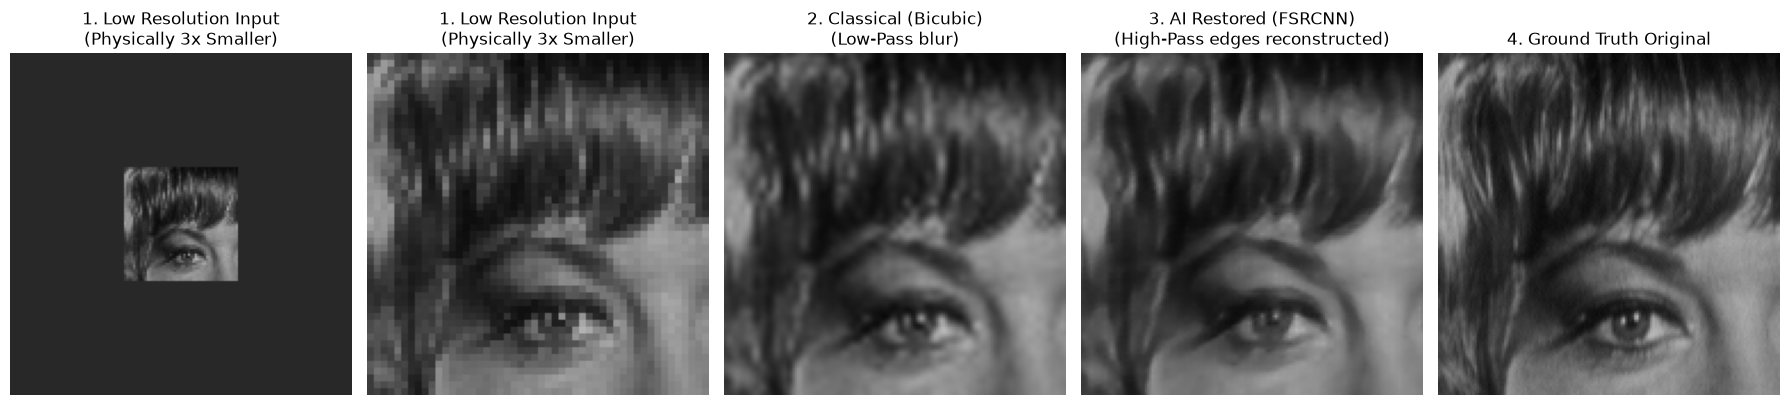

In [ ]:
crop_y, crop_x = 150, 150
size = 150

def crop_pixelated(low_res_img):
    # 1. Find the corresponding crop coordinates in the 3x smaller image
    sy, sx = crop_y // 3, crop_x // 3
    ssize = size // 3  
    
    # 2. Extract the tiny 50x50 patch
    tiny_crop = low_res_img[sy : sy+ssize, sx : sx+ssize]
    
    # 3. Scale it back up to 150x150 using Nearest Neighbor to force it to be blocky
    pixelated_crop = cv2.resize(tiny_crop, (size, size), interpolation=cv2.INTER_NEAREST)
    
    if len(pixelated_crop.shape) == 3 and pixelated_crop.shape[2] == 3:
        return cv2.cvtColor(pixelated_crop, cv2.COLOR_BGR2RGB)
    return pixelated_crop

def crop_large(img):
    # Standard crop for the full-resolution images
    crop = img[crop_y : crop_y+size, crop_x : crop_x+size]
    # Ensure it's in RGB for Matplotlib if not already
    if len(crop.shape) == 3 and crop.shape[2] == 3:
        return cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    return crop

def crop_small_padded(low_res_img):
    # 1. Calculate the equivalent crop coordinates for the 3x smaller image
    sy, sx = crop_y // 3, crop_x // 3
    ssize = size // 3  # This will be a 50x50 patch
    
    # 2. Extract the tiny patch and convert color
    tiny_crop = low_res_img[sy : sy+ssize, sx : sx+ssize]
    if len(tiny_crop.shape) == 3 and tiny_crop.shape[2] == 3:
        tiny_crop = cv2.cvtColor(tiny_crop, cv2.COLOR_BGR2RGB)
    elif len(tiny_crop.shape) == 2:
        tiny_crop = cv2.cvtColor(tiny_crop, cv2.COLOR_GRAY2RGB)
    
    # 3. Create a dark gray 150x150 canvas so Matplotlib has something full-sized to display
    canvas = np.ones((size, size, 3), dtype=np.uint8) * 40
    
    # 4. Paste the tiny patch directly into the center of the canvas
    offset = (size - ssize) // 2
    canvas[offset : offset+ssize, offset : offset+ssize] = tiny_crop
    
    return canvas

# ==========================================
# PLOTTING THE RESULTS
# ==========================================
plt.figure(figsize=(18, 6))

plt.subplot(1, 5, 1)
# Use our new padded function for the first image only!
plt.imshow(crop_small_padded(low_res)) 
plt.title("1. Low Resolution Input\n(Physically 3x Smaller)")
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(crop_pixelated(low_res)) 
plt.title("1. Low Resolution Input\n(Physically 3x Smaller)")
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(crop_large(classical_restored))
plt.title("2. Classical (Bicubic)\n(Low-Pass blur)")
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(crop_large(ai_restored))
plt.title("3. AI Restored (FSRCNN)\n(High-Pass edges reconstructed)")
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(crop_large(original_img))
plt.title("4. Ground Truth Original")
plt.axis('off')

plt.tight_layout()
plt.show()

## AI Deblurring

install onnxruntime using command

``pip install onnxruntime``

Then clone the repo from https://huggingface.co/opencv/deblurring_nafnet

Loading ONNX model and running inference...


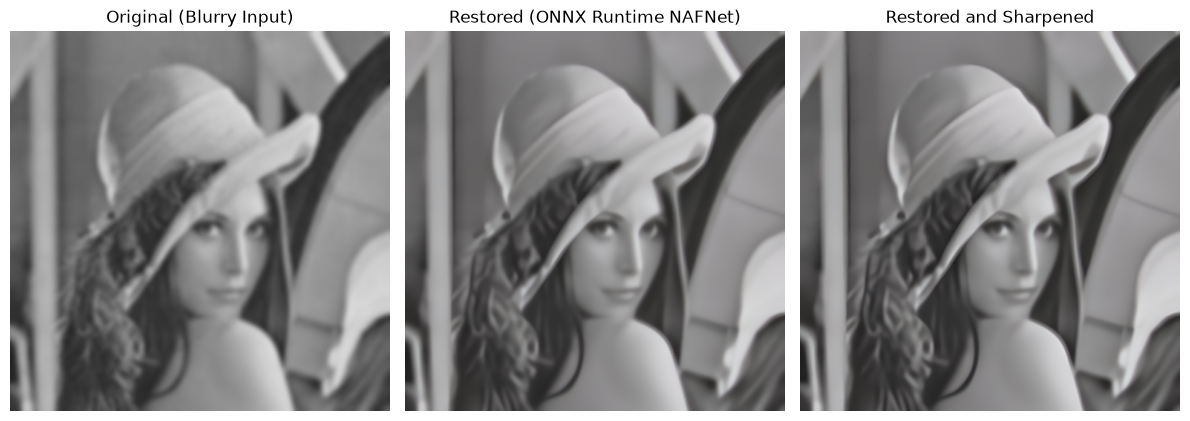

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import onnxruntime as ort

# Load the blurry image and convert BGR to RGB
img = cv2.imread('lena_blur.jpg') 
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Deep Learning models expect floating point numbers between 0.0 and 1.0, not 0 to 255
input_tensor = img.astype(np.float32) / 255.0

# OpenCV stores images as (Height, Width, Channels)
# ONNX models usually expect (Channels, Height, Width), so we transpose it
input_tensor = np.transpose(input_tensor, (2, 0, 1))

# The model expects a "batch" of images, even if we are only sending one.
# We add an extra dimension at the front: (1, Channels, Height, Width)
input_tensor = np.expand_dims(input_tensor, axis=0)

# ==========================================
# 2. RUN ONNX RUNTIME INFERENCE
# ==========================================
print("Loading ONNX model and running inference...")

# Initialize the ONNX session with your NAFNet model
# (Update the path if the model is in a subfolder)
session = ort.InferenceSession("deblurring_nafnet/deblurring_nafnet_2025may.onnx")

# Get the name of the model's input layer automatically
input_name = session.get_inputs()[0].name

# Run the mathematical forward pass
# We pass the input_tensor mapped to the input_name
outputs = session.run(None, {input_name: input_tensor})

# ==========================================
# 3. POST-PROCESS THE OUTPUT TENSOR
# ==========================================
# The output is a tensor shaped (1, Channels, Height, Width). 
# We need to turn it back into a standard image.

# Remove the batch dimension -> (Channels, Height, Width)
output_tensor = np.squeeze(outputs[0], axis=0)

# Transpose back to OpenCV/Matplotlib format -> (Height, Width, Channels)
restored_img = np.transpose(output_tensor, (1, 2, 0))

# The model might output values slightly outside 0.0 - 1.0 due to math approximations,
# so we clip them, multiply by 255, and convert back to 8-bit integers.
restored_img = np.clip(restored_img, 0.0, 1.0) # Adjust these values!
restored_img = (restored_img * 255.0).astype(np.uint8)

# 1. Create a slightly blurred version of the AI's output
smoothed_ai = cv2.GaussianBlur(restored_img, (9, 9), 10.0)

# 2. Subtract the blur from the original to isolate the edges, then add them back.
# Formula: final = (AI_Image * 1.5) - (Smoothed_AI * 0.5)
hybrid_sharpened = cv2.addWeighted(restored_img, 1.5, smoothed_ai, -0.5, 0)

# ==========================================
# --- SHOW RESULTS ---
# ==========================================
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original (Blurry Input)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(restored_img)
plt.title("Restored (ONNX Runtime NAFNet)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hybrid_sharpened)
plt.title("Restored and Sharpened")
plt.axis('off')

plt.tight_layout()
plt.show()

## Lets's Do Some Challenges!

Based on what you'd practice so far, guess the words on these images.

### Challenge 1

Guess the words on the trash bins.

![challenge 1](guess_the_words/q_1.png)

### Challenge 2

Guess the words surrounding the license plate.

![challenge 2](guess_the_words/q_2.jpg)

### Challenge 3

Guess the words on the plate.

![challenge 2](guess_the_words/q_3.png)